# NDT Localization

Our goal is to find where the car is on a pre-built map by matching each LiDAR scan to the map using NDT (Normal Distributions Transform).
The position error must stay below **1.2 meters** and the car must travel at least **170 meters**.

Since the car moves on a flat road, we work in **2D** with a 3-DoF pose `(x, y, yaw)`. This makes the Jacobians and Hessians compact and the alignment fast.

In [1]:
import open3d as o3d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
from typing import Tuple, List

DATA_DIR = "dataset"
FRAMES_DIR = os.path.join(DATA_DIR, "frames")

## Parameters

| Parameter | Value | Meaning |
|---|---|---|
| `MAP_VOXEL` | 0.25 m | Voxel size for downsampling the map |
| `SCAN_VOXEL` | 0.25 m | Voxel size for downsampling each LiDAR scan |
| `CELL_SIZE` | 1.5 m | Size of one NDT cell in the 2D grid |
| `MIN_PTS_PER_CELL` | 3 | A cell needs at least this many points to form a valid Gaussian |
| `MAX_ITER` | 50 | Maximum Newton iterations per frame |
| `TOLERANCE` | 1e-5 | Stop early if the step size falls below this |
| `Z_MIN`, `Z_MAX` | 0.5, 7.0 m | Height band applied to both map and scan - drops ground + overhead noise so the 2D projection keeps useful structure |

In [2]:
MAP_VOXEL = 0.25
SCAN_VOXEL = 0.25
CELL_SIZE = 1.5
MIN_PTS_PER_CELL = 3
MAX_ITER = 50
TOLERANCE = 1e-5
Z_MIN = 0.5
Z_MAX = 7.0

In [3]:
def downsample_voxel(points: np.ndarray, voxel_size: float) -> np.ndarray:
    """Voxel-grid downsampling that returns the voxel CENTER coordinates
    (matches the helper used in the NDT reference notebook)."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size)
    indices = np.array([v.grid_index for v in voxel_grid.get_voxels()], dtype=float) * voxel_size
    min_bound = voxel_grid.get_min_bound()
    indices += min_bound + voxel_size / 2
    return indices

def filter_z(points: np.ndarray, z_min: float = Z_MIN, z_max: float = Z_MAX) -> np.ndarray:
    """Drop the ground plane and any tall stuff so only mid-height structure
    survives - this keeps the 2D projection meaningful."""
    mask = (points[:, 2] > z_min) & (points[:, 2] < z_max)
    return points[mask]

def rotation_matrix_yaw(yaw: float) -> np.ndarray:
    c, s = np.cos(yaw), np.sin(yaw)
    return np.array([[c, -s], [s, c]])

In [4]:
# Load and downsample the map
map_pcd = o3d.io.read_point_cloud(os.path.join(DATA_DIR, "map.pcd"))
map_array = np.asarray(map_pcd.points)
print(f"Raw map points: {len(map_array)}")

map_downsampled = downsample_voxel(map_array, MAP_VOXEL)
print(f"Downsampled map points: {len(map_downsampled)}")

# Same height filter that we will apply to every scan
map_for_ndt = filter_z(map_downsampled)
print(f"Map points after height filter: {len(map_for_ndt)}")

# Load ground truth
gt = pd.read_csv(os.path.join(DATA_DIR, "ground_truth.csv"), skipinitialspace=True)
gt.columns = gt.columns.str.strip()
gt = gt.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f"Ground truth frames: {len(gt)}")
print(gt.head())

Raw map points: 143949
Downsampled map points: 106740
Map points after height filter: 27303
Ground truth frames: 1014
   Frame    x    y         z  roll  pitch  yaw
0      0  0.0  0.0  0.000000   0.0    0.0  0.0
1      1  0.0  0.0  0.015636   0.0    0.0  0.0
2      2  0.0  0.0  0.005846   0.0    0.0  0.0
3      3  0.0  0.0  0.005628   0.0    0.0  0.0
4      4  0.0  0.0  0.005628   0.0    0.0  0.0


## NDT Algorithm

NDT replaces the per-point nearest-neighbour matching of ICP with a smooth probabilistic model of the map.

**Building the grid (once):**

1. Overlay a 2D grid of square cells over the map.
2. For every cell that contains at least `MIN_PTS_PER_CELL` points, compute the mean `mu` and covariance `Sigma` of the points inside it. Each cell becomes a 2D Gaussian.
3. Pre-compute `Sigma^-1` and regularize any near-singular cell by adding a small multiple of the identity.

**Aligning a scan (Newton's method):**

For pose `p = (x, y, yaw)` we maximise the score `s(p) = sum_i exp(-0.5 q_i^T Sigma_c^-1 q_i)` where `q_i = T(p) x_i - mu_c` is the offset of the transformed scan point from the mean of its cell.

One iteration:

1. Transform the scan with the current pose.
2. Look up the cell each transformed point belongs to.
3. Build the gradient `g` and Hessian `H` of the score over all valid points (vectorized with `np.einsum`).
4. Make `H` positive definite, solve `delta = -H^-1 g`.
5. Run a small line search to pick a step size `alpha`, update `p <- p + alpha * delta`.
6. Stop when `max(|alpha * delta|) < TOLERANCE`.

In [5]:
class Pose:
    """2D pose (x, y, yaw)."""
    def __init__(self, x: float, y: float, yaw: float):
        self.x = x
        self.y = y
        self.yaw = yaw

    def get_transformation(self) -> Tuple[np.ndarray, np.ndarray]:
        R = rotation_matrix_yaw(self.yaw)
        t = np.array([[self.x], [self.y]])
        return R, t

    def copy(self):
        return Pose(self.x, self.y, self.yaw)


class Cell:
    """One NDT grid cell - stores the 2D Gaussian fit to the points inside."""
    def __init__(self):
        self.mean = None
        self.cov = None
        self.cov_inv = None

    def set_points(self, points: np.ndarray) -> None:
        if len(points) >= MIN_PTS_PER_CELL:
            self.mean = np.mean(points[:, :2], axis=0)
            cov = np.cov(points[:, :2].T)
            # Regularize near-singular covariance (collinear cells)
            eigvals = np.linalg.eigvalsh(cov)
            if eigvals.min() < 0.001 * eigvals.max():
                cov += np.eye(2) * 0.001 * eigvals.max()
            self.cov = cov
            try:
                self.cov_inv = np.linalg.inv(cov)
            except np.linalg.LinAlgError:
                self.cov_inv = None
        else:
            self.mean = None
            self.cov = None
            self.cov_inv = None

In [6]:
class NDT:
    """2D Normal Distributions Transform with Newton's method alignment.

    Fully vectorized: score, gradient and Hessian are computed over all valid
    points at once via flat-array fancy indexing and einsum - no Python loops
    inside the alignment iterations."""

    def __init__(self, x_step: float, y_step: float,
                 xlim: List[float] = None, ylim: List[float] = None):
        self.x_step = x_step
        self.y_step = y_step
        self.xlim = xlim
        self.ylim = ylim
        self.grid = None
        self._grid_w = 0
        self._grid_h = 0
        self._flat_means = None
        self._flat_cov_invs = None
        self._flat_cell_map = None

    # --- Grid construction ---------------------------------------------------

    def set_input_cloud(self, pcd: np.ndarray) -> None:
        x_min_pcd, y_min_pcd = np.min(pcd[:, :2], axis=0) - 1
        x_max_pcd, y_max_pcd = np.max(pcd[:, :2], axis=0) + 1

        if self.xlim is None:
            self.xlim = [x_min_pcd, x_max_pcd]
        if self.ylim is None:
            self.ylim = [y_min_pcd, y_max_pcd]

        x_min, x_max = self.xlim
        y_min, y_max = self.ylim

        nvx = int(np.ceil((x_max - x_min) / self.x_step))
        nvy = int(np.ceil((y_max - y_min) / self.y_step))
        xs = np.linspace(x_min, x_max, nvx)
        ys = np.linspace(y_min, y_max, nvy)

        self._grid_w = nvx - 1
        self._grid_h = nvy - 1
        self.grid = [[Cell() for _ in range(self._grid_w)] for _ in range(self._grid_h)]

        cols = np.clip(np.searchsorted(xs, pcd[:, 0], side='right') - 1, 0, self._grid_w - 1)
        rows = np.clip(np.searchsorted(ys, pcd[:, 1], side='right') - 1, 0, self._grid_h - 1)
        flat_keys = rows * self._grid_w + cols
        order = np.argsort(flat_keys)
        sorted_keys = flat_keys[order]
        change = np.flatnonzero(np.diff(sorted_keys)) + 1
        starts = np.concatenate([[0], change])
        ends = np.concatenate([change, [len(sorted_keys)]])
        for i in range(len(starts)):
            r, c = divmod(int(sorted_keys[starts[i]]), self._grid_w)
            self.grid[r][c].set_points(pcd[order[starts[i]:ends[i]]])

        self._build_flat_arrays()

    def _build_flat_arrays(self):
        means, cov_invs = [], []
        cell_map = np.full((self._grid_h, self._grid_w), -1, dtype=np.int32)
        idx = 0
        for r in range(self._grid_h):
            for c in range(self._grid_w):
                cell = self.grid[r][c]
                if cell.cov_inv is not None:
                    cell_map[r, c] = idx
                    means.append(cell.mean)
                    cov_invs.append(cell.cov_inv)
                    idx += 1
        self._flat_means = np.array(means) if means else np.empty((0, 2))
        self._flat_cov_invs = np.array(cov_invs) if cov_invs else np.empty((0, 2, 2))
        self._flat_cell_map = cell_map

    # --- Vectorized cell lookup ----------------------------------------------

    def _cell_indices(self, pts_2d: np.ndarray):
        cols = np.floor((pts_2d[:, 0] - self.xlim[0]) / self.x_step).astype(np.int32)
        rows = np.floor((pts_2d[:, 1] - self.ylim[0]) / self.y_step).astype(np.int32)
        valid = (cols >= 0) & (cols < self._grid_w) & (rows >= 0) & (rows < self._grid_h)
        return rows, cols, valid

    def _valid_point_data(self, pts_2d: np.ndarray):
        rows, cols, in_grid = self._cell_indices(pts_2d)
        if not np.any(in_grid):
            return None, None
        v_rows, v_cols = rows[in_grid], cols[in_grid]
        flat_idx = self._flat_cell_map[v_rows, v_cols]
        has_cell = flat_idx >= 0
        if not np.any(has_cell):
            return None, None
        return pts_2d[in_grid][has_cell], flat_idx[has_cell]

    # --- Newton's method alignment -------------------------------------------

    def align(self, pcd: np.ndarray, init_pose: Pose,
              max_iterations: int = MAX_ITER, eps: float = TOLERANCE) -> Pose:
        pose = init_pose
        pcd_2d = pcd[:, :2]

        for _ in range(max_iterations):
            R, t = pose.get_transformation()
            transformed = (R @ pcd_2d.T + t).T

            score, delta_T = self._score_and_newton(transformed, pose)
            alpha = self.compute_step_length(delta_T, pcd_2d, pose, score)

            step = alpha * delta_T.flatten()
            pose.x += step[0]
            pose.y += step[1]
            pose.yaw += step[2]

            if pose.yaw > 2 * np.pi:
                pose.yaw -= np.floor(pose.yaw / (2 * np.pi)) * (2 * np.pi)

            if np.max(np.abs(step)) < eps:
                break

        return pose

    # --- Score + Newton step (vectorized) ------------------------------------

    def calculate_score(self, points: np.ndarray) -> float:
        pts = points[:, :2] if points.shape[1] > 2 else points
        vp, idx = self._valid_point_data(pts)
        if vp is None:
            return 0.0
        q = vp - self._flat_means[idx]
        q_cinv = np.einsum('ni,nij->nj', q, self._flat_cov_invs[idx])
        return float(np.sum(np.exp(-0.5 * np.sum(q_cinv * q, axis=1))))

    def _score_and_newton(self, pcd: np.ndarray, pose: Pose):
        pts = pcd[:, :2] if pcd.shape[1] > 2 else pcd
        vp, idx = self._valid_point_data(pts)

        if vp is None:
            H = self.pos_definite(np.zeros((3, 3)), 0, 5)
            return 0.0, (-np.linalg.inv(H) @ np.zeros(3)).reshape(3, 1)

        n = vp.shape[0]
        means = self._flat_means[idx]
        cov_invs = self._flat_cov_invs[idx]

        q = vp - means
        q_cinv = np.einsum('ni,nij->nj', q, cov_invs)
        expo = np.exp(-0.5 * np.sum(q_cinv * q, axis=1))

        score = float(np.sum(expo))

        # Jacobian formulated in terms of the already-transformed coords
        J = np.zeros((n, 2, 3))
        J[:, 0, 0] = 1.0
        J[:, 1, 1] = 1.0
        J[:, 0, 2] = -(vp[:, 1] - pose.y)
        J[:, 1, 2] =  vp[:, 0] - pose.x

        g_per_pt = np.einsum('nk,nkj->nj', q_cinv, J) * expo[:, None]
        gradient = g_per_pt.sum(axis=0)

        a = -np.einsum('nk,nkj->nj', q_cinv, J)
        H1 = -np.einsum('ni,nj,n->ij', a, a, expo)

        dq2_0 = -(vp[:, 0] - pose.x)
        dq2_1 = -(vp[:, 1] - pose.y)
        v2 = -(q_cinv[:, 0] * dq2_0 + q_cinv[:, 1] * dq2_1)
        H2 = np.zeros((3, 3))
        H2[2, 2] = -np.sum(expo * v2)

        cinv_J = np.einsum('nab,nbc->nac', cov_invs, J)
        H3 = np.einsum('nba,nbc,n->ac', J, cinv_J, expo)

        H = self.pos_definite(H1 + H2 + H3, 0, 5)
        delta_T = (-np.linalg.inv(H) @ gradient).reshape(3, 1)

        return score, delta_T

    def pos_definite(self, H: np.ndarray, start: float, increment: float,
                     max_iterations: int = 100) -> np.ndarray:
        """Add lambda*I until H is positive definite."""
        I = np.eye(H.shape[0])
        pos_H = H + start * I
        for _ in range(max_iterations):
            if np.all(np.linalg.eigvalsh(pos_H) > 0):
                break
            pos_H = pos_H + increment * I
        return pos_H

    # --- Line search ---------------------------------------------------------

    def compute_step_length(self, T: np.ndarray, source_2d: np.ndarray,
                            pose: Pose, curr_score: float) -> float:
        T = T.copy()
        max_param = max(T[0, 0], max(T[1, 0], T[2, 0]))
        mlength = 1.0
        if max_param > 0.2:
            mlength = 0.1 / max_param
            T *= mlength

        best_alpha = 0.0
        alpha = 1.0
        for _ in range(40):
            adj_score = self._score_at_alpha(alpha, T, source_2d, pose)
            if adj_score > curr_score:
                best_alpha = alpha
                curr_score = adj_score
            alpha *= 0.7

        if best_alpha == 0.0:
            alpha = 2.0
            for _ in range(10):
                adj_score = self._score_at_alpha(alpha, T, source_2d, pose)
                if adj_score > curr_score:
                    best_alpha = alpha
                    curr_score = adj_score
                alpha *= 2

        return best_alpha * mlength

    def _score_at_alpha(self, alpha: float, T: np.ndarray,
                        source_2d: np.ndarray, pose: Pose) -> float:
        dx, dy, dyaw = T[0, 0] * alpha, T[1, 0] * alpha, T[2, 0] * alpha
        yaw = pose.yaw + dyaw
        if yaw > 2 * np.pi:
            yaw -= np.floor(yaw / (2 * np.pi)) * (2 * np.pi)
        c, s = np.cos(yaw), np.sin(yaw)
        tx, ty = pose.x + dx, pose.y + dy
        rx = c * source_2d[:, 0] - s * source_2d[:, 1] + tx
        ry = s * source_2d[:, 0] + c * source_2d[:, 1] + ty
        return self.calculate_score(np.column_stack([rx, ry]))

In [7]:
# Build the NDT grid once from the z-filtered downsampled map.
ndt = NDT(x_step=CELL_SIZE, y_step=CELL_SIZE)
t0 = time.time()
ndt.set_input_cloud(map_for_ndt)
print(f"NDT grid built in {time.time() - t0:.2f}s "
      f"({ndt._grid_h} x {ndt._grid_w} cells, "
      f"{len(ndt._flat_means)} populated)")

row0 = gt.iloc[0]
current_pose = Pose(row0['x'], row0['y'], row0['yaw'])

num_frames = len(gt)
estimated_positions = []
gt_positions = []
lateral_errors = []
times = []

for i in range(num_frames):
    t_start = time.time()

    frame_path = os.path.join(FRAMES_DIR, f"frame_{i}.pcd")
    if not os.path.exists(frame_path):
        continue

    scan_pcd = o3d.io.read_point_cloud(frame_path)
    scan_pts = np.asarray(scan_pcd.points)

    scan_pts = downsample_voxel(scan_pts, SCAN_VOXEL)
    scan_pts = filter_z(scan_pts)

    # Use the previous pose as the initial guess, NDT refines this with Newton's method
    current_pose = ndt.align(scan_pts, current_pose.copy(),
                             max_iterations=MAX_ITER, eps=TOLERANCE)

    est_x, est_y = current_pose.x, current_pose.y
    estimated_positions.append([est_x, est_y])

    gt_row = gt.iloc[i]
    gt_x, gt_y, gt_yaw = gt_row['x'], gt_row['y'], gt_row['yaw']
    gt_positions.append([gt_x, gt_y])

    # Lateral error
    dx, dy = est_x - gt_x, est_y - gt_y
    lat_err = abs(-np.sin(gt_yaw) * dx + np.cos(gt_yaw) * dy)
    lateral_errors.append(lat_err)

    times.append(time.time() - t_start)

    if i % 100 == 0:
        print(f"Frame {i}/{num_frames-1} | Lateral error: {lat_err:.4f}m | Time: {times[-1]:.3f}s | Scan: {len(scan_pts)} pts")

estimated_positions = np.array(estimated_positions)
gt_positions = np.array(gt_positions)
print(f"\nDone. Processed {len(lateral_errors)} frames.")

NDT grid built in 0.22s (41 x 152 cells, 731 populated)
Frame 0/1013 | Lateral error: 0.0245m | Time: 0.124s | Scan: 1117 pts
Frame 100/1013 | Lateral error: 0.0112m | Time: 0.217s | Scan: 1665 pts
Frame 200/1013 | Lateral error: 0.0488m | Time: 0.406s | Scan: 2048 pts
Frame 300/1013 | Lateral error: 0.0071m | Time: 0.427s | Scan: 2144 pts
Frame 400/1013 | Lateral error: 0.0365m | Time: 0.386s | Scan: 1822 pts
Frame 500/1013 | Lateral error: 0.2166m | Time: 0.189s | Scan: 1420 pts
Frame 600/1013 | Lateral error: 0.0755m | Time: 0.224s | Scan: 1594 pts
Frame 700/1013 | Lateral error: 0.0059m | Time: 0.274s | Scan: 1803 pts
Frame 800/1013 | Lateral error: 0.0611m | Time: 0.192s | Scan: 866 pts
Frame 900/1013 | Lateral error: 0.3012m | Time: 0.157s | Scan: 410 pts
Frame 1000/1013 | Lateral error: 0.2028m | Time: 0.152s | Scan: 478 pts

Done. Processed 1014 frames.


## Visualization

The plots below show the lateral error per frame and the estimated trajectory compared to the ground truth.

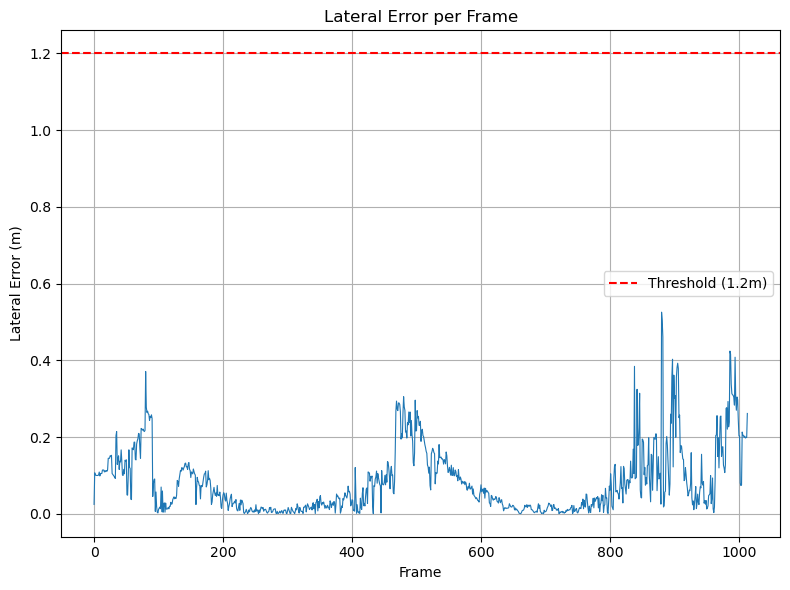

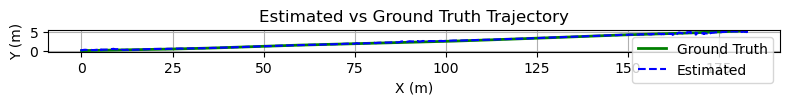

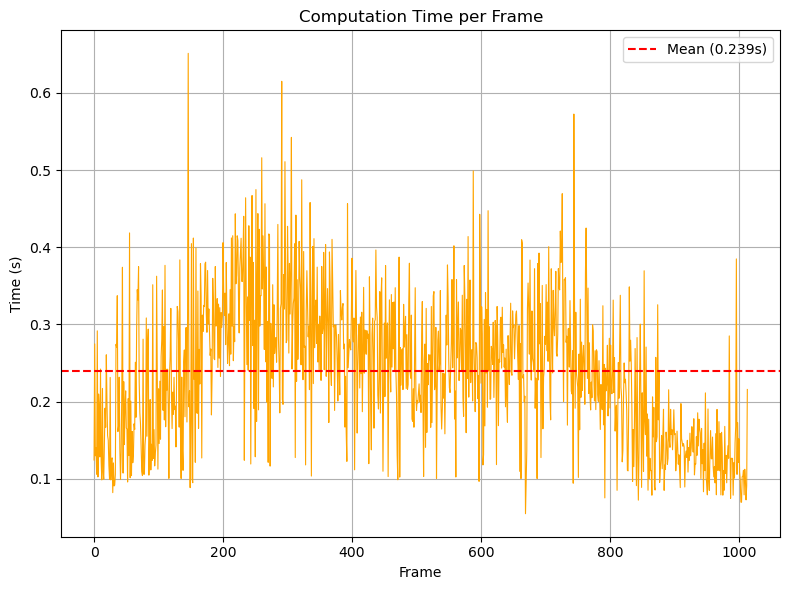

In [8]:
# Lateral error per frame
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(lateral_errors, linewidth=0.8)
ax1.axhline(y=1.2, color='r', linestyle='--', label='Threshold (1.2m)')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Lateral Error (m)')
ax1.set_title('Lateral Error per Frame')
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()

# Estimated vs ground truth trajectory
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.plot(gt_positions[:, 0], gt_positions[:, 1], 'g-', label='Ground Truth', linewidth=2)
ax2.plot(estimated_positions[:, 0], estimated_positions[:, 1], 'b--', label='Estimated', linewidth=1.5)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_title('Estimated vs Ground Truth Trajectory')
ax2.legend()
ax2.grid(True)
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()

# Computation time per frame
fig3, ax3 = plt.subplots(figsize=(8, 6))
ax3.plot(times, linewidth=0.8, color='orange')
ax3.axhline(y=np.mean(times), color='r', linestyle='--', label=f'Mean ({np.mean(times):.3f}s)')
ax3.set_xlabel('Frame')
ax3.set_ylabel('Time (s)')
ax3.set_title('Computation Time per Frame')
ax3.legend()
ax3.grid(True)
plt.tight_layout()
plt.show()

## Performance Metrics

Summary of the localization results across all frames.

In [9]:
diffs = np.diff(estimated_positions, axis=0)
distances = np.sqrt(np.sum(diffs ** 2, axis=1))
total_distance = np.sum(distances)

print("=" * 50)
print("NDT LOCALIZATION RESULTS")
print("=" * 50)
print(f"Max lateral error:      {max(lateral_errors):.4f} m")
print(f"Mean lateral error:     {np.mean(lateral_errors):.4f} m")
print(f"Total distance:         {total_distance:.2f} m")
print(f"Mean time per frame:    {np.mean(times):.4f} s")
print(f"Frames processed:       {len(lateral_errors)}")
print("=" * 50)
print(f"Max error < 1.2m:       {'PASS' if max(lateral_errors) < 1.2 else 'FAIL'}")
print(f"Distance > 170m:        {'PASS' if total_distance > 170 else 'FAIL'}")

NDT LOCALIZATION RESULTS
Max lateral error:      0.5254 m
Mean lateral error:     0.0827 m
Total distance:         192.43 m
Mean time per frame:    0.2395 s
Frames processed:       1014
Max error < 1.2m:       PASS
Distance > 170m:        PASS
